<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Python_for_AI/blob/main/Decorators_and_Namespaces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Namespace
- A namespace is essentially a mapping between names and objects, and Python resolves names using the LEGB rule
- Local → Enclosing → Global → Built-in.

- there are 4 types of namespaces:
  - Built in namespace
  - Global namespace
  - Enclosing namespace
  - Local namespaces

### Scope --> textual region of the program where a namespace is directly accessible

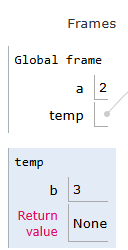

In [ ]:
# local and global
# global var
a = 2

def temp():
  # local var
  b = 3
  print(b)

temp()
print(a)

3
2


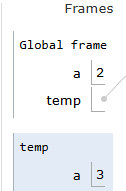

In [ ]:
# local and global --> same name
# here both variables name are same but both exist in completely different namespaces, so there is no ambiguity

a = 2

def temp():
  # local var
  a = 3
  print(a)

temp()
print(a)

3
2


In [ ]:
# local and global --> local does not have but global has
a = 2

def temp():
  # local var
  print(a)

temp()
print(a)


2
2


In [ ]:
# local and global -> editing global

a = 2

def temp():
  # local var
  a += 1
  print(a)

temp()
print(a)

UnboundLocalError: cannot access local variable 'a' where it is not associated with a value

In [ ]:
# global keyword used to access the global scope variable
# not a good programming practice

a = 2

def temp():
  # local var
  global a
  a += 1
  print(a)

temp()
print(a)

3
3


In [ ]:
# local and global -> global created inside local
# this will create a global variable from a local namepace

def temp():
  # local var
  global a
  a = 1
  print(a)

temp()
print(a)

1
1


In [ ]:
# local and global -> function parameter is local
def temp(z):
  # local var
  print(z)

a = 5
temp(5)
print(a)
print(z)


# here z is a local variable or a global variable?
# ans: z --> local variable

5
5


NameError: name 'z' is not defined

In [ ]:
a = 2

def temp():
  # local var
  a = 0
  global a
  a += 1
  print(a)

temp()
print(a)

SyntaxError: name 'a' is assigned to before global declaration (3677612793.py, line 6)

In [ ]:
# built in scope

import builtins

print(dir(builtins))

['ArithmeticError', 'AssertionError', 'AttributeError', 'BaseException', 'BaseExceptionGroup', 'BlockingIOError', 'BrokenPipeError', 'BufferError', 'BytesWarning', 'ChildProcessError', 'ConnectionAbortedError', 'ConnectionError', 'ConnectionRefusedError', 'ConnectionResetError', 'DeprecationWarning', 'EOFError', 'Ellipsis', 'EncodingWarning', 'EnvironmentError', 'Exception', 'ExceptionGroup', 'False', 'FileExistsError', 'FileNotFoundError', 'FloatingPointError', 'FutureWarning', 'GeneratorExit', 'IOError', 'ImportError', 'ImportWarning', 'IndentationError', 'IndexError', 'InterruptedError', 'IsADirectoryError', 'KeyError', 'KeyboardInterrupt', 'LookupError', 'MemoryError', 'ModuleNotFoundError', 'NameError', 'None', 'NotADirectoryError', 'NotImplemented', 'NotImplementedError', 'OSError', 'OverflowError', 'PendingDeprecationWarning', 'PermissionError', 'ProcessLookupError', 'RecursionError', 'ReferenceError', 'ResourceWarning', 'RuntimeError', 'RuntimeWarning', 'StopAsyncIteration', 'S

In [ ]:
# renaming built-ins
# here the max in built in scope (originally used to retrieve the max element of the list), is redesigned by writing it in the global scope.
# so according to the LEGB rule global scope is first accessed before the built in scope.
# so here the max function overwrites the max function in the built in scope

# here the first max will work since the first max accessess the built-in max(since at this time max in global scope has not been created yet)
# the second max will not work, since it will access the global scope max()

# visualize through python tutor

L = [1,2,3]
print(max(L))
def max():
  print('hello')

print(max(L))

TypeError: max() takes 0 positional arguments but 1 was given

In [ ]:
# enclosing scope  (non local)
def outer():
  def inner():
    print("inner fxn")
  inner()
  print("outer function")

outer()
print("main program")

inner fxn
outer function
main program


In [ ]:
# nonlocal keyword  --> we can change the nonlocal variable from the local scope (not a good programming method)
def outer():
  a = 1
  def inner():
    nonlocal a
    a += 1
    print('inner',a)
  inner()
  print('outer',a)


outer()
print('main program')

inner 2
outer 2
main program


In [ ]:
# functions, if else etc. dont create a seperate namespace. Their namespace is same as the namespace of the function

### Decorators

A decorator in python is a function that receives another function as input and adds some functionality(decoration) to and it and returns it.

This can happen only because python functions are 1st class citizens.

There are 2 types of decorators available in python
- `Built in decorators` like `@staticmethod`, `@classmethod`, `@abstractmethod` and `@property` etc
- `User defined decorators` that we programmers can create according to our needs

In [ ]:
# 1st class citizens
# In Python, functions are first-class citizens (or first-class objects).
# This means that functions are treated like any other object — you can:

# Assign them to variables
# Pass them as arguments to other functions
# Return them from other functions
# Store them in data structures (lists, dictionaries, etc.)

In [ ]:
# Python are 1st class function

def modify(func,num):
  return func(num)

def square(num):
  return num**2

modify(square,2)

4

In [ ]:
def my_decorator(func):
  def wrapper():
    print("---------------")
    func()
    print("---------------")
  return wrapper

def func():
  print("Hello")

a = my_decorator(func)
a()

---------------
Hello
---------------


In [ ]:
# shortform of using the decorator

def my_decorator(func):
  def wrapper():
    print("---------------")
    func()
    print("---------------")
  return wrapper

@my_decorator
def func():
  print("Hello")

func()

---------------
Hello
---------------


In [ ]:
import time

# this code will not work if the fucntions have any parameters

def timer(func):
  def wrapper():
    start = time.time()
    func()
    end = time.time()
    print("Time taken by ", func.__name__, " is ", end - start)
  return wrapper

@timer
def calculate_square_4():
  for i in range(4):
    print(i**2)

@timer
def calculate_square_10():
  for i in range(10):
    print(i**2)

calculate_square_4()
calculate_square_10()



0
1
4
9
Time taken by  calculate_square_4  is  4.002033472061157
0
1
4
9
16
25
36
49
64
81
Time taken by  calculate_square_10  is  4.506111145019531e-05


In [ ]:
# anything meaningful?
import time

def timer(func):
  def wrapper(*args):
    start = time.time()
    func(*args)
    print('time taken by',func.__name__,time.time()-start,'secs')
  return wrapper

@my_decorator
def hello():
  print('hello world')
  time.sleep(2)

@timer
def square(num):
  time.sleep(1)
  print(num**2)

@timer
def power(a,b):
  print(a**b)

hello()
square(2)
power(2,3)



---------------
hello world
---------------
4
time taken by square 1.000234603881836 secs
8
time taken by power 1.2874603271484375e-05 secs


In [ ]:
# custom decorator that checks the data type of the input of the function
# decorator with an input

# something like this:

# @checkdt(int)
# def square(num):
#   print(num**2)

def sanity_check(data_type):
  def outer_wrapper(func):
    def inner_wrapper(*args):
      if type(*args) == data_type:
        func(*args)
      else:
        print("Chal Hatt......")
    return inner_wrapper
  return outer_wrapper

@sanity_check(int)
def square(num):
  print(num**2)

square("hehe")


Chal Hatt......


In [ ]:
square(3)

9


#Iteration
- general termfor taking each item of something one after another. Any time you use a loop, explicit or implicit to go over a group of them is called iteration.

# Iterator
- an object that allows the programmer to traverse through a sequence of data without having to store the entire data in the memory.
- `doesn't load the entire data into the memory at once`

In [ ]:
import sys
L = [x for x in range(1,100000)]

# for i in L:
#   print(i*2)
print(sys.getsizeof(L))



# range() is an iterable and hence it takes less space in memory, it does does not loads the entire data in the memory at once.
x = range(1,11111111111111)

# for i in x:
#   print(i*2)

print(sys.getsizeof(x))

800984
48


# Iterable
- is an object which one can iterate over
- it generates an iterator when passes to an iter( ) method

In [ ]:
# kisi bhi cheez ke upar agar loop chala skte hain to wo ek iterable hai
# in above example list and range both are iterable

# iterable
L = [1,2,3]

# iter(L) is an iterator
type(iter(L))


list_iterator

#**Important**
- Every iterator is and iterable
- Not all iterables are iterators

# **Trick**
- Every iterable has an iter() method which can be verified with dir()
- Every iterator has an iter() method and next() method

In [ ]:
a = 2
print(dir(a))

['__abs__', '__add__', '__and__', '__bool__', '__ceil__', '__class__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__float__', '__floor__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__le__', '__lshift__', '__lt__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rlshift__', '__rmod__', '__rmul__', '__ror__', '__round__', '__rpow__', '__rrshift__', '__rshift__', '__rsub__', '__rtruediv__', '__rxor__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__truediv__', '__trunc__', '__xor__', 'as_integer_ratio', 'bit_count', 'bit_length', 'conjugate', 'denominator', 'from_bytes', 'imag', 'is_integer', 'numerator', 'real', 'to_bytes']


In [ ]:
L = [1,2,3]
print(dir(a))

# L has an iter() method so it is an iterable.
# it does not have a next() method so it is not an iterator

['__abs__', '__add__', '__and__', '__bool__', '__ceil__', '__class__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__float__', '__floor__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__le__', '__lshift__', '__lt__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rlshift__', '__rmod__', '__rmul__', '__ror__', '__round__', '__rpow__', '__rrshift__', '__rshift__', '__rsub__', '__rtruediv__', '__rxor__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__truediv__', '__trunc__', '__xor__', 'as_integer_ratio', 'bit_count', 'bit_length', 'conjugate', 'denominator', 'from_bytes', 'imag', 'is_integer', 'numerator', 'real', 'to_bytes']


In [ ]:
dir(iter(L))

# after iter(L) it has both iter() and next() , so now it has become and iterator.

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__length_hint__',
 '__lt__',
 '__ne__',
 '__new__',
 '__next__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__']

# How for loop works

In [2]:
num = [1,2,3]

# step 1
iter_num = iter(num)

# step 2 --> next
print(next(iter_num))
print(next(iter_num))
print(next(iter_num))
print(next(iter_num))


1
2
3


StopIteration: 

# Making own for loop

In [5]:
def own_for_loop(iterable):

  iterator = iter(iterable)

  while True:
    try:
      print(next(iterator))
    except StopIteration:
      break

In [10]:
a = [1,2,3,4]
b = range(1,11)
c = (5,67,42)
d = {1,2,3,4}

e = {1:2, 2:4}

own_for_loop(e)


1
2


In [11]:
# IMPORTANT


num = [1,2,3,4]
iter_obj = iter(num)

print(id(iter_obj),"Address of iterator of iterable")

iter_obj2 = iter(iter_obj)
print(id(iter_obj2),"Address of iterator of iterator")

# when you first run iter() on iterable it gives iterable
# when you run iter() on previously obtained iterator it returns itself.

135940164326576 Address of iterator of iterable
135940164326576 Address of iterator of iterator


### Creating our own range function

In [23]:
class own_range:

  def __init__(self, start, end):
    self.start = start
    self.end = end

  def __iter__(self):
    return own_range_iterator(self)

In [24]:
class own_range_iterator:

  def __init__(self,iterable_obj) -> None:
    self.iterable_obj = iterable_obj

  def __iter__(self):
    return self

  def __next__(self):
    if self.iterable_obj.start >= self.iterable_obj.end:
      raise StopIteration

    current = self.iterable_obj.start
    self.iterable_obj.start += 1
    return current

In [25]:
for i in own_range(1,22):
  print(i)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21


### application  -->  for e.g. loading large image datasets while in deep learning



---



#**GENERATORS**

- simple way of creating iterators
- instead of return it has yield

In [27]:
def gen_demo():

  yield "first"
  yield "second"
  yield "third"


obj = gen_demo()

for i in obj:
  print(i)

first
second
third


In [28]:
def square(num):
  for i in range(1, num+1):
    yield i**2

In [29]:
gen = square(10)

print(next(gen))
print(next(gen))
print(next(gen))

for i in gen:
  print(i)

1
4
9
16
25
36
49
64
81
100


# Range function using generator

In [35]:
def range_using_generator(start, end):
  for i in range(start, end):
    yield i

In [36]:
gen = range_using_generator(15,26)

for i in gen:
  print(i)

15
16
17
18
19
20
21
22
23
24
25


# more simplified form of generator --> generator expression

In [37]:
# List comprehension
l = [i**2 for i in range(1,101)]

In [38]:
# generator expression
gen = (i**2 for i in range(1,101))

for i in gen:
  print(i)

1
4
9
16
25
36
49
64
81
100
121
144
169
196
225
256
289
324
361
400
441
484
529
576
625
676
729
784
841
900
961
1024
1089
1156
1225
1296
1369
1444
1521
1600
1681
1764
1849
1936
2025
2116
2209
2304
2401
2500
2601
2704
2809
2916
3025
3136
3249
3364
3481
3600
3721
3844
3969
4096
4225
4356
4489
4624
4761
4900
5041
5184
5329
5476
5625
5776
5929
6084
6241
6400
6561
6724
6889
7056
7225
7396
7569
7744
7921
8100
8281
8464
8649
8836
9025
9216
9409
9604
9801
10000


# Practical example

In [ ]:
# in deep learning loading a large dataset of images by loading them one by one in the program by using generators

import os
import cv2

def image_data_reader(folder_path):

    for file in os.listdir(folder_path):
        f_array = cv2.imread(os.path.join(folder_path,file))
        yield f_array

In [ ]:
gen = image_data_reader('C:/Users/91842/emotion-detector/train/Sad')

next(gen)
next(gen)

next(gen)
next(gen)

###Memory Efficient

In [45]:
L = [x for x in range(100000)]
gen = (x for x in range(100000))

import sys

print('Size of L in memory',sys.getsizeof(L))
print('Size of gen in memory',sys.getsizeof(gen))

Size of L in memory 800984
Size of gen in memory 192


###Representing Infinite Streams

In [43]:
def all_even():
    n = 0
    while True:
        yield n
        n += 2

In [44]:
even_num_gen = all_even()
next(even_num_gen)
next(even_num_gen)

2

###Chaining Generators

In [42]:
def fibonacci_numbers(nums):
    x, y = 0, 1
    for _ in range(nums):
        x, y = y, x+y
        yield x

def square(nums):
    for num in nums:
        yield num**2

print(sum(square(fibonacci_numbers(10))))

4895
